In [ ]:
import pandas as pd
import numpy as np

# Replace 'data.csv' with the actual name of your CSV file
try:
  df = pd.read_csv('Cancer_Data.csv')
  display(df.head())
except FileNotFoundError:
  print("Error: 'Cancer_Data.csv' not found. Please replace it with the correct file path or name.")

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

def train(k):
  # Drop the 'id' and 'Unnamed: 32' columns as they are not features
  X = df.drop(['id', 'diagnosis', 'Unnamed: 32'], axis=1)
  y = df['diagnosis']

  # Use the entire dataset for training and testing
  X_train, X_test, y_train, y_test = X, X, y, y

  # Create a KNN classifier instance
  knn = KNeighborsClassifier(n_neighbors=k) # Use the 'k' defined in the prediction cell

  # Train the model
  knn.fit(X_train, y_train)

  # Make predictions on the test set (which is the entire dataset)
  return knn.predict(X_test), y_test


In [ ]:
def params(predictions, y_test):
  TP = TN = FP = FN = 0
  for x, y in zip(predictions, y_test):
    if x == 'B' and y == 'B':
      TP+=1
    elif x == 'B' and y != 'B':
      TN+=1
    elif x == 'M' and y == 'M':
      FP+=1
    elif x == 'M' and y != 'M':
      FN+=1

  # print(f'{TP=}, {TN=}, {FP=}, {FN=}')
  return TP, TN, FP, FN

In [ ]:
TP = []
TN = []
FP = []
FN = []
Accuracy = []
Precision = []
Recall = []
n = 30
x = [i for i in range(1, n)]
for k in range(1, n):
  m = params(*train(k))
  print(m)
  TP.append(m[0])
  TN.append(m[1])
  FP.append(m[2])
  FN.append(m[3])
  Accuracy.append((m[0] + m[-1])/(sum(m)))
  Precision.append((m[0])/(m[0] + m[2]))
  Recall.append(m[0]/(m[0] + m[-1]))

(357, 0, 212, 0)
(357, 30, 182, 0)
(351, 19, 193, 6)
(354, 26, 186, 3)
(348, 21, 191, 9)
(351, 24, 188, 6)
(346, 21, 191, 11)
(347, 24, 188, 10)
(345, 21, 191, 12)
(347, 25, 187, 10)
(345, 22, 190, 12)
(345, 25, 187, 12)
(345, 23, 189, 12)
(349, 26, 186, 8)
(347, 24, 188, 10)
(347, 27, 185, 10)
(347, 27, 185, 10)
(348, 29, 183, 9)
(347, 28, 184, 10)
(348, 29, 183, 9)
(347, 29, 183, 10)
(348, 30, 182, 9)
(347, 30, 182, 10)
(349, 31, 181, 8)
(348, 31, 181, 9)
(349, 31, 181, 8)
(349, 31, 181, 8)
(349, 31, 181, 8)
(349, 31, 181, 8)


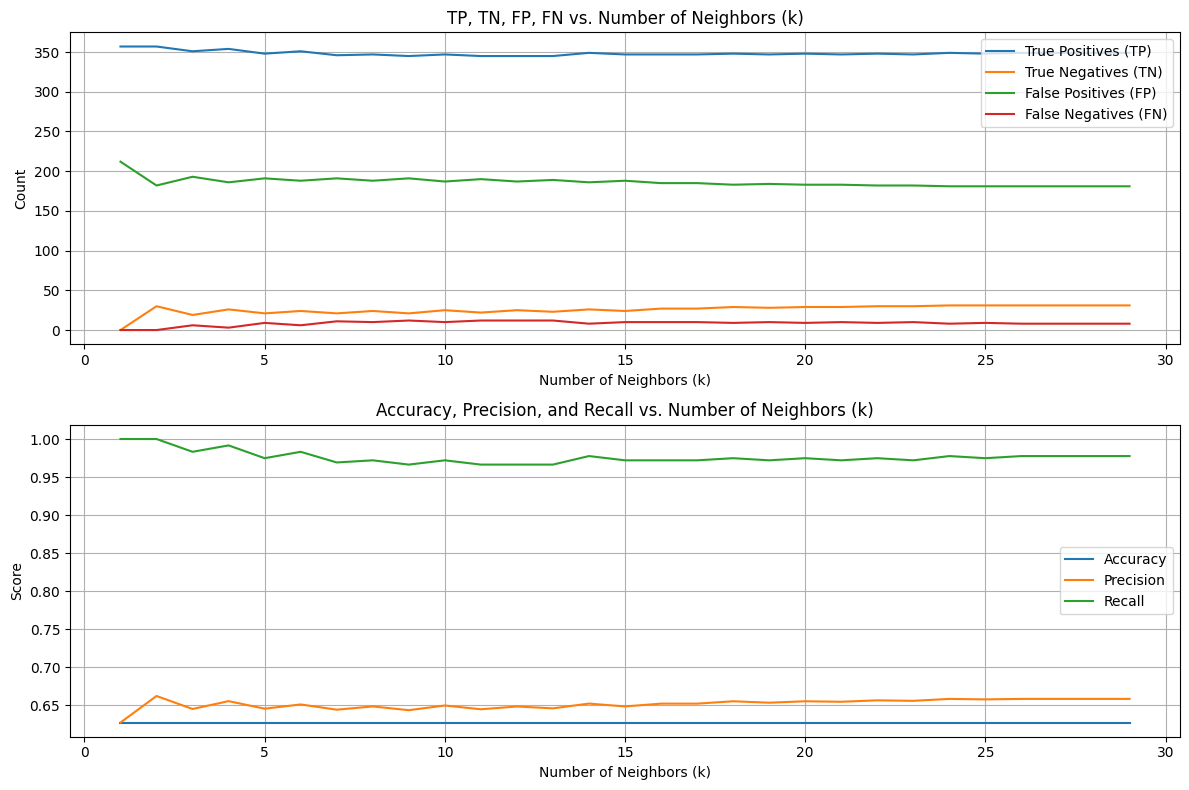

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Plot for TP, TN, FP, FN
plt.subplot(2, 1, 1) # Create a subplot for these metrics
plt.plot(x, TP, label='True Positives (TP)')
plt.plot(x, TN, label='True Negatives (TN)')
plt.plot(x, FP, label='False Positives (FP)')
plt.plot(x, FN, label='False Negatives (FN)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Count')
plt.title('TP, TN, FP, FN vs. Number of Neighbors (k)')
plt.legend()
plt.grid(True)

# Plot for Accuracy, Precision, Recall
plt.subplot(2, 1, 2) # Create a new subplot for these metrics
plt.plot(x, Accuracy, label='Accuracy')
plt.plot(x, Precision, label='Precision')
plt.plot(x, Recall, label='Recall')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Score')
plt.title('Accuracy, Precision, and Recall vs. Number of Neighbors (k)')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [ ]:
def rho(x, y, weights):
  S = 0
  for i, (xi, yi) in enumerate(zip(x, y)):
    S += weights[i]*(xi - yi)**2

  return np.sqrt(S)

def my_knn(i, data, k, weights):
  min = [0 for j in range(k)]
  # data = np.delete(data, i)
  for j in range(k):
    min[j] = rho(data[i], data[j], weights)

  print(min)


def params(predictions, data):
  TP = TN = FP = FN = 0
  for x, y in zip(predictions, data):
    if x == 'B' and y == 'B':
      TP+=1
    elif x == 'B' and y != 'B':
      TN+=1
    elif x == 'M' and y == 'M':
      FP+=1
    elif x == 'M' and y != 'M':
      FN+=1

  # print(f'{TP=}, {TN=}, {FP=}, {FN=}')
  return TP, TN, FP, FN

In [ ]:
X = df.drop(['id', 'diagnosis', 'Unnamed: 32'], axis=1)
Y = df['diagnosis']

X = X.to_numpy()
Y = Y.to_numpy()
k = 1

weights = [1 for i in range(len(X))]
my_knn(1, X, k, weights)

[np.float64(341.7302620944424)]


np.float64(17.99)

---

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor

import lightgbm as lgb
from lightgbm import LGBMClassifier, LGBMRegressor

# !pip install catboost
import catboost as cb
from catboost import CatBoostClassifier, CatBoostRegressor

In [ ]:
# data = pd.read_csv('Cancer_data.csv')
data = pd.read_csv('Cancer_Data.csv')

# Предобработка данных
# Удаление ненужных столбцов (если есть)
if 'id' in data.columns:
    data = data.drop('id', axis=1)
if 'Unnamed: 32' in data.columns:
    data = data.drop('Unnamed: 32', axis=1)

# Кодирование целевой переменной (diagnosis)
le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])  # M=1, B=0

# Разделение на признаки и целевую переменную
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(' '*24 + 'Accuracy' + ' '*4 +'Recall' + ' '*4 + 'Precision')

max_depth=3

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=max_depth, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print(f"XGBoost Accuracy   : {accuracy_score(y_test, xgb_pred):10.4f} {precision_score(y_test, xgb_pred):10.4f} {recall_score(y_test, xgb_pred):10.4f}")

# LightGBM
lgb_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=max_depth, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
print(f"LightBoost Accuracy: {accuracy_score(y_test, lgb_pred):10.4f} {precision_score(y_test, lgb_pred):10.4f} {recall_score(y_test, lgb_pred):10.4f}")

# CatBoost
cb_model = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=max_depth, random_state=42, verbose=False)
cb_model.fit(X_train, y_train)
cb_pred = cb_model.predict(X_test)
print(f"CatBoost Accuracy  : {accuracy_score(y_test, cb_pred):10.4f} {precision_score(y_test, cb_pred):10.4f} {recall_score(y_test, cb_pred):10.4f}")


                        Accuracy    Recall    Precision
XGBoost Accuracy   :     0.9561     0.9524     0.9302
LightBoost Accuracy:     0.9561     0.9750     0.9070
CatBoost Accuracy  :     0.9737     0.9762     0.9535


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


Начало тестирования моделей на различных наборах признаков...

Тестирование набора: Все столбцы
Количество признаков: 30
Признаки: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
Обучение XGBoost...
  XGBoost: Accuracy = 0.9649, Время обучения = 0.10с
Обучение LightGBM...
  LightGBM: Accuracy = 0.9737, Время обучения = 0.05с
Обучение CatBoost...
  CatBoost: Accuracy = 0.9737, Время обучения = 0.25с

Тестирование набора: Только mean
Количество признаков: 10
Признаки: ['radius_mean', 'texture_mean',

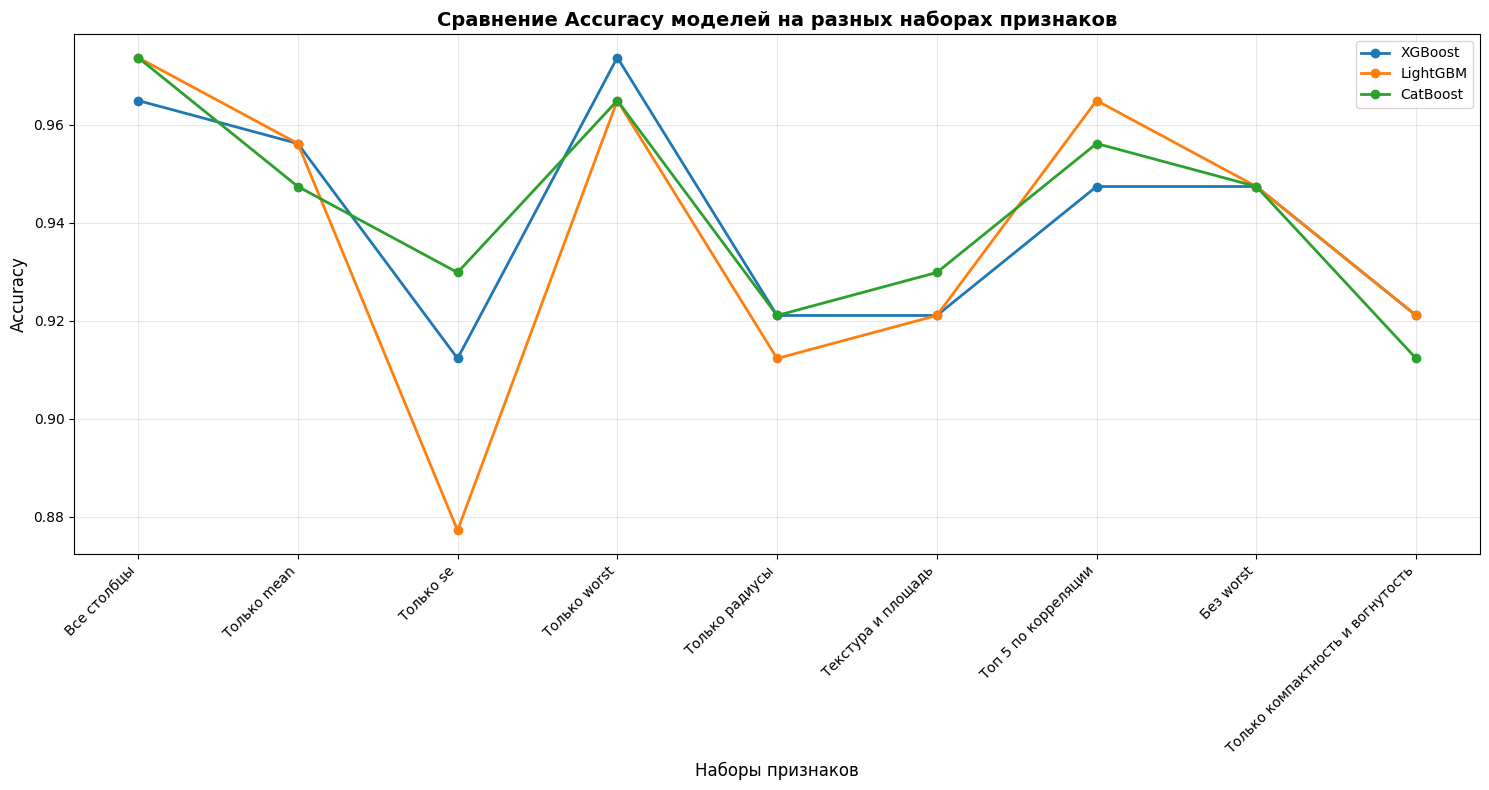


ЛУЧШАЯ КОМБИНАЦИЯ:
Модель: LightGBM
Набор признаков: Все столбцы
Количество признаков: 30
Accuracy: 0.9737
F1-Score: 0.9630
Время обучения: 0.05с


In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import time

# Отключение предупреждений
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_csv('Cancer_Data.csv')

# Предобработка данных
if 'id' in data.columns:
    data = data.drop('id', axis=1)
if 'Unnamed: 32' in data.columns:
    data = data.drop('Unnamed: 32', axis=1)

le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])  # M=1, B=0

# Определение различных наборов столбцов
column_sets = {
    'Все столбцы': data.drop('diagnosis', axis=1).columns.tolist(),

    'Только mean': data.filter(like='mean').columns.tolist(),

    'Только se': data.filter(like='se').columns.tolist(),

    'Только worst': data.filter(like='worst').columns.tolist(),

    'Только радиусы': data.filter(regex='^radius').columns.tolist(),

    'Текстура и площадь': data.filter(regex='texture|area').columns.tolist(),

    'Топ 5 по корреляции': ['radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst', 'radius_mean'],

    'Без worst': [col for col in data.columns if 'worst' not in col and col != 'diagnosis'],

    'Только компактность и вогнутость': data.filter(regex='compactness|concavity').columns.tolist()
}

# Функция для вычисления метрик
def evaluate_model(model, X_test, y_test, model_name, feature_set):
    start_time = time.time()
    y_pred = model.predict(X_test)
    end_time = time.time()

    return {
        'Модель': model_name,
        'Набор признаков': feature_set,
        'Количество признаков': X_test.shape[1],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Время предсказания (с)': end_time - start_time
    }

# Основная функция тестирования
def test_models_on_feature_sets():
    results = []

    for feature_set_name, features in column_sets.items():
        print(f"\n{'='*50}")
        print(f"Тестирование набора: {feature_set_name}")
        print(f"Количество признаков: {len(features)}")
        print(f"Признаки: {features}")

        # Подготовка данных
        X = data[features]
        y = data['diagnosis']

        # Масштабирование признаков
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_scaled = pd.DataFrame(X_scaled, columns=features)

        # Разделение на train/test
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )

        # Модели
        models = {
            'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
            'LightGBM': LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, verbose=-1),
            'CatBoost': CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, random_state=42, verbose=False)
        }

        # Обучение и оценка моделей
        for model_name, model in models.items():
            print(f"Обучение {model_name}...")

            # Обучение модели
            train_start = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - train_start

            # Оценка модели
            metrics = evaluate_model(model, X_test, y_test, model_name, feature_set_name)
            metrics['Время обучения (с)'] = train_time
            results.append(metrics)

            print(f"  {model_name}: Accuracy = {metrics['Accuracy']:.4f}, "
                  f"Время обучения = {train_time:.2f}с")

    return pd.DataFrame(results)

# Запуск тестирования
print("Начало тестирования моделей на различных наборах признаков...")
results_df = test_models_on_feature_sets()

# Анализ результатов
print(f"\n{'='*80}")
print("ОБЩИЕ РЕЗУЛЬТАТЫ:")
print('='*80)

# Лучшие результаты по accuracy
best_results = results_df.sort_values('Accuracy', ascending=False).head(10)
print("\nТоп-10 результатов по Accuracy:")
print(best_results[['Модель', 'Набор признаков', 'Количество признаков',
                   'Accuracy', 'F1-Score', 'Время обучения (с)']].to_string(index=False))

# Сравнение моделей
print(f"\n{'='*50}")
print("СРАВНЕНИЕ МОДЕЛЕЙ:")
print('='*50)

model_comparison = results_df.groupby('Модель').agg({
    'Accuracy': ['mean', 'max', 'min'],
    'F1-Score': ['mean', 'max', 'min'],
    'Время обучения (с)': 'mean',
    'Время предсказания (с)': 'mean'
}).round(4)

print(model_comparison)

# Сравнение наборов признаков
print(f"\n{'='*50}")
print("СРАВНЕНИЕ НАБОРОВ ПРИЗНАКОВ:")
print('='*50)

feature_comparison = results_df.groupby('Набор признаков').agg({
    'Accuracy': ['mean', 'max', 'min'],
    'Количество признаков': 'first'
}).round(4)

print(feature_comparison)

# Визуализация результатов (опционально)
import matplotlib.pyplot as plt

# Создание графика
plt.figure(figsize=(15, 8))

# Группировка данных для графика
for model in results_df['Модель'].unique():
    model_data = results_df[results_df['Модель'] == model]
    plt.plot(model_data['Набор признаков'], model_data['Accuracy'],
             marker='o', label=model, linewidth=2)

plt.title('Сравнение Accuracy моделей на разных наборах признаков', fontsize=14, fontweight='bold')
plt.xlabel('Наборы признаков', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод лучшей комбинации
best_overall = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\n{'='*80}")
print("ЛУЧШАЯ КОМБИНАЦИЯ:")
print(f"Модель: {best_overall['Модель']}")
print(f"Набор признаков: {best_overall['Набор признаков']}")
print(f"Количество признаков: {best_overall['Количество признаков']}")
print(f"Accuracy: {best_overall['Accuracy']:.4f}")
print(f"F1-Score: {best_overall['F1-Score']:.4f}")
print(f"Время обучения: {best_overall['Время обучения (с)']:.2f}с")
print('='*80)

In [ ]:
# Анализ важности признаков для лучшей модели
def analyze_feature_importance():
    # Используем все признаки для анализа важности
    X_all = data.drop('diagnosis', axis=1)
    y_all = data['diagnosis']

    # Обучаем модели на всех признаках
    models = {
        'XGBoost': XGBClassifier(random_state=42),
        'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
        'CatBoost': CatBoostClassifier(random_state=42, verbose=False)
    }

    feature_importance_df = pd.DataFrame()
    feature_importance_df['Feature'] = X_all.columns

    for model_name, model in models.items():
        model.fit(X_all, y_all)

        if hasattr(model, 'feature_importances_'):
            feature_importance_df[model_name] = model.feature_importances_
        elif hasattr(model, 'get_feature_importance'):
            feature_importance_df[model_name] = model.get_feature_importance()

    # Нормализация важности признаков
    for model in models.keys():
        if model in feature_importance_df.columns:
            feature_importance_df[model] = feature_importance_df[model] / feature_importance_df[model].max()

    # Средняя важность по всем моделям
    model_cols = [col for col in feature_importance_df.columns if col != 'Feature']
    feature_importance_df['Average_Importance'] = feature_importance_df[model_cols].mean(axis=1)

    # Топ-10 самых важных признаков
    top_features = feature_importance_df.nlargest(10, 'Average_Importance')

    print("\nТоп-10 самых важных признаков по всем моделям:")
    print(top_features[['Feature', 'Average_Importance']].to_string(index=False))

    return top_features

# Запуск анализа важности признаков
top_features = analyze_feature_importance()


Топ-10 самых важных признаков по всем моделям:
             Feature  Average_Importance
        radius_worst            0.678610
       texture_worst            0.677823
concave points_worst            0.594745
     perimeter_worst            0.562053
 concave points_mean            0.531443
          area_worst            0.509343
        texture_mean            0.420302
             area_se            0.319896
     concavity_worst            0.311970
    smoothness_worst            0.279988


Начало тестирования моделей с анализом Jaccard similarity ошибок...

Тестирование набора: Все столбцы
Количество признаков: 30
Обучение XGBoost...
  XGBoost: Accuracy = 0.9649, Ошибок = 4
Обучение LightGBM...
  LightGBM: Accuracy = 0.9737, Ошибок = 3
Обучение CatBoost...
  CatBoost: Accuracy = 0.9737, Ошибок = 3

Матрица Jaccard similarity ошибок для Все столбцы:
          XGBoost  LightGBM  CatBoost
XGBoost      1.00      0.75      0.75
LightGBM     0.75      1.00      0.50
CatBoost     0.75      0.50      1.00

Тестирование набора: Только mean
Количество признаков: 10
Обучение XGBoost...
  XGBoost: Accuracy = 0.9561, Ошибок = 5
Обучение LightGBM...
  LightGBM: Accuracy = 0.9561, Ошибок = 5
Обучение CatBoost...
  CatBoost: Accuracy = 0.9474, Ошибок = 6

Матрица Jaccard similarity ошибок для Только mean:
          XGBoost  LightGBM  CatBoost
XGBoost     1.000     0.667     0.833
LightGBM    0.667     1.000     0.833
CatBoost    0.833     0.833     1.000

Тестирование набора: Только se


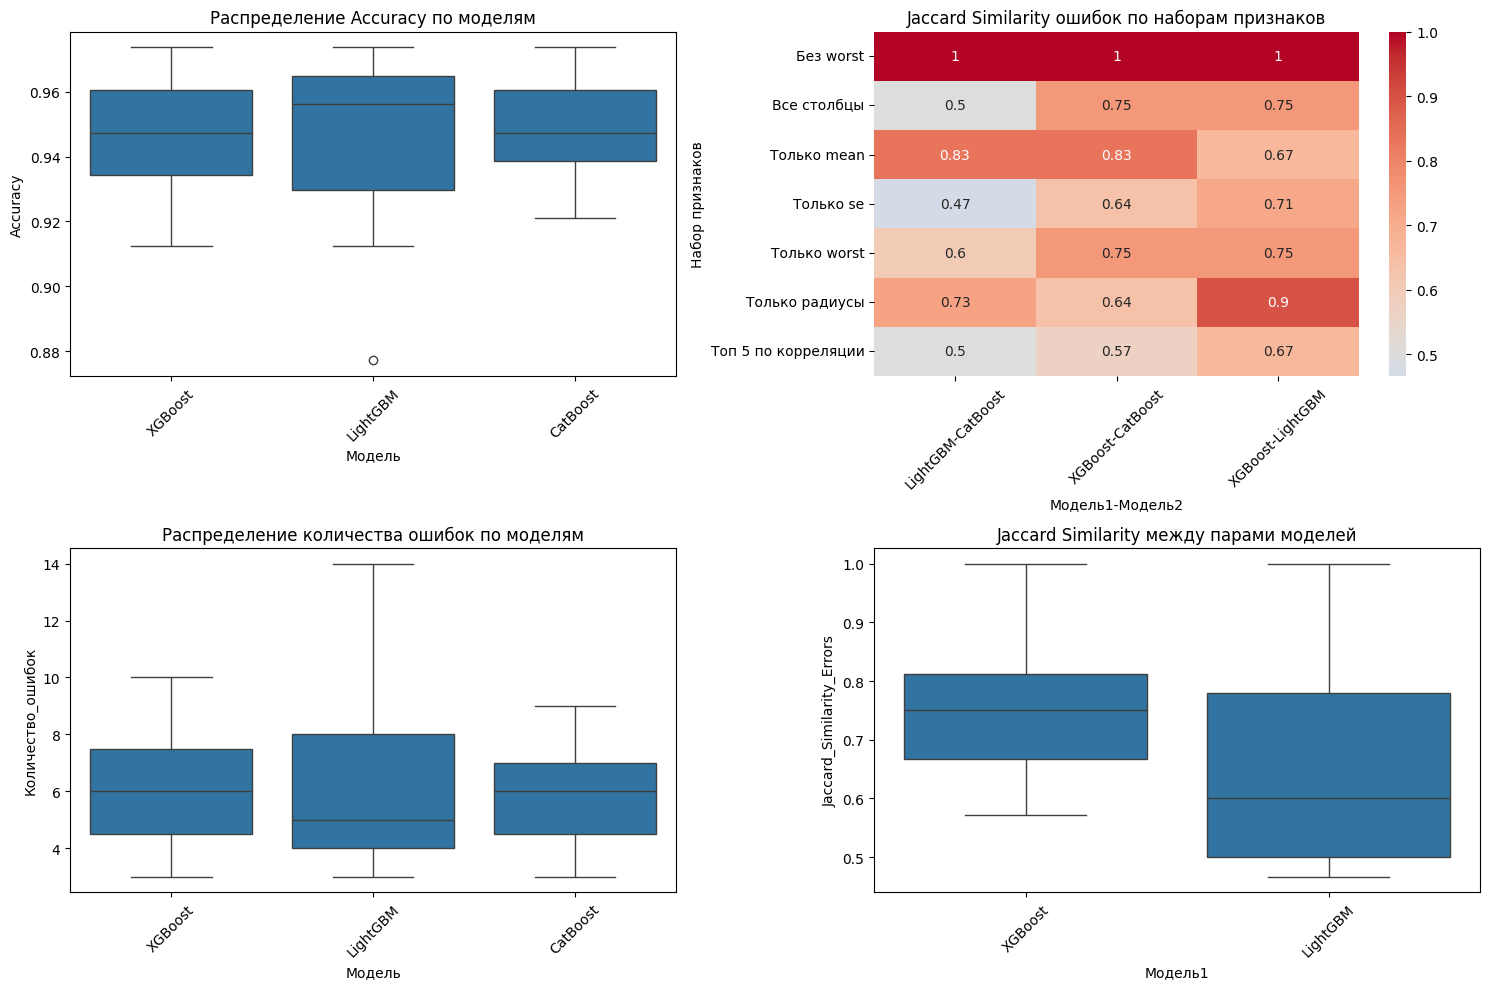


ВЫВОДЫ:
Лучшая модель по Accuracy: LightGBM на Все столбцы (Accuracy: 0.9737)
Лучшая пара для ансамблирования: LightGBM + CatBoost на Только se (Jaccard similarity ошибок: 0.4667)
Средняя Jaccard similarity ошибок между всеми парами моделей: 0.7263

Интерпретация Jaccard similarity ошибок:
0.0 - модели ошибаются на совершенно разных примерах
0.5 - модели ошибаются на половине одинаковых примеров
1.0 - модели ошибаются на одних и тех же примерах


In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import time
from itertools import combinations

# Отключение предупреждений
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_csv('Cancer_Data.csv')

# Предобработка данных
if 'id' in data.columns:
    data = data.drop('id', axis=1)
if 'Unnamed: 32' in data.columns:
    data = data.drop('Unnamed: 32', axis=1)

le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])  # M=1, B=0

# Определение различных наборов столбцов
column_sets = {
    'Все столбцы': data.drop('diagnosis', axis=1).columns.tolist(),
    'Только mean': data.filter(like='mean').columns.tolist(),
    'Только se': data.filter(like='se').columns.tolist(),
    'Только worst': data.filter(like='worst').columns.tolist(),
    'Только радиусы': data.filter(regex='^radius').columns.tolist(),
    'Топ 5 по корреляции': ['radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst', 'radius_mean'],
    'Без worst': [col for col in data.columns if 'worst' not in col and col != 'diagnosis'],
}

# Функция для вычисления ошибок (где модель ошиблась)
def get_error_mask(y_true, y_pred):
    """Возвращает маску ошибок: 1 где ошибка, 0 где правильно"""
    return (y_true != y_pred).astype(int)

# Функция для вычисления метрик Jaccard между ошибками моделей
def calculate_jaccard_on_errors(error_masks):
    """Вычисляет матрицу Jaccard similarity между ошибками моделей"""
    models = list(error_masks.keys())
    jaccard_matrix = np.zeros((len(models), len(models)))

    for i, model1 in enumerate(models):
        for j, model2 in enumerate(models):
            if i == j:
                jaccard_matrix[i, j] = 1.0  # Совпадение с самим собой
            else:
                # Jaccard similarity между наборами ошибок
                errors1 = error_masks[model1]
                errors2 = error_masks[model2]

                intersection = np.sum((errors1 == 1) & (errors2 == 1))
                union = np.sum((errors1 == 1) | (errors2 == 1))

                if union == 0:
                    jaccard_matrix[i, j] = 1.0
                else:
                    jaccard_matrix[i, j] = intersection / union

    return jaccard_matrix, models

# Функция для вычисления всех метрик
def evaluate_model(model, X_test, y_test, model_name, feature_set):
    start_time = time.time()
    y_pred = model.predict(X_test)
    end_time = time.time()

    # Маска ошибок
    error_mask = get_error_mask(y_test, y_pred)

    return {
        'Модель': model_name,
        'Набор признаков': feature_set,
        'Количество признаков': X_test.shape[1],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Jaccard_True': jaccard_score(y_test, y_pred),  # Jaccard для правильных предсказаний
        'Количество_ошибок': np.sum(error_mask),
        'Доля_ошибок': np.mean(error_mask),
        'Время предсказания (с)': end_time - start_time,
        'Error_Mask': error_mask,
        'Predictions': y_pred
    }

# Основная функция тестирования
def test_models_with_jaccard_analysis():
    all_results = []
    jaccard_comparisons = []

    for feature_set_name, features in column_sets.items():
        print(f"\n{'='*60}")
        print(f"Тестирование набора: {feature_set_name}")
        print(f"Количество признаков: {len(features)}")

        # Подготовка данных
        X = data[features]
        y = data['diagnosis']

        # Масштабирование признаков
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_scaled = pd.DataFrame(X_scaled, columns=features)

        # Разделение на train/test
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )

        # Модели
        models = {
            'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
            'LightGBM': LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, verbose=-1),
            'CatBoost': CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, random_state=42, verbose=False)
        }

        # Обучение и оценка моделей
        error_masks = {}
        feature_results = []

        for model_name, model in models.items():
            print(f"Обучение {model_name}...")

            # Обучение модели
            train_start = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - train_start

            # Оценка модели
            metrics = evaluate_model(model, X_test, y_test, model_name, feature_set_name)
            metrics['Время обучения (с)'] = train_time
            feature_results.append(metrics)

            # Сохраняем маски ошибок для Jaccard сравнения
            error_masks[model_name] = metrics['Error_Mask']

            print(f"  {model_name}: Accuracy = {metrics['Accuracy']:.4f}, "
                  f"Ошибок = {metrics['Количество_ошибок']}")

        # Анализ Jaccard similarity между ошибками моделей
        jaccard_matrix, model_names = calculate_jaccard_on_errors(error_masks)

        # Сохраняем результаты Jaccard сравнения
        for i, model1 in enumerate(model_names):
            for j, model2 in enumerate(model_names):
                if i < j:  # Чтобы избежать дублирования
                    jaccard_comparisons.append({
                        'Набор признаков': feature_set_name,
                        'Модель1': model1,
                        'Модель2': model2,
                        'Jaccard_Similarity_Errors': jaccard_matrix[i, j],
                        'Количество_признаков': len(features)
                    })

        all_results.extend(feature_results)

        # Вывод матрицы Jaccard для текущего набора признаков
        print(f"\nМатрица Jaccard similarity ошибок для {feature_set_name}:")
        jaccard_df = pd.DataFrame(jaccard_matrix, index=model_names, columns=model_names)
        print(jaccard_df.round(3))

    return pd.DataFrame(all_results), pd.DataFrame(jaccard_comparisons)

# Запуск тестирования
print("Начало тестирования моделей с анализом Jaccard similarity ошибок...")
results_df, jaccard_df = test_models_with_jaccard_analysis()

# Анализ результатов
print(f"\n{'='*80}")
print("ОБЩИЕ РЕЗУЛЬТАТЫ ПО МОДЕЛЯМ:")
print('='*80)

# Лучшие результаты по accuracy
best_results = results_df.sort_values('Accuracy', ascending=False).head(10)
print("\nТоп-10 результатов по Accuracy:")
print(best_results[['Модель', 'Набор признаков', 'Количество признаков',
                   'Accuracy', 'F1-Score', 'Количество_ошибок']].to_string(index=False))

# Анализ Jaccard similarity между ошибками
print(f"\n{'='*80}")
print("АНАЛИЗ JACCARD SIMILARITY МЕЖДУ ОШИБКАМИ МОДЕЛЕЙ:")
print('='*80)

# Средняя Jaccard similarity между парами моделей
jaccard_summary = jaccard_df.groupby(['Модель1', 'Модель2']).agg({
    'Jaccard_Similarity_Errors': ['mean', 'std', 'min', 'max']
}).round(4)

print("\nСтатистика Jaccard similarity между парами моделей:")
print(jaccard_summary)

# Jaccard similarity по наборам признаков
print(f"\n{'='*50}")
print("JACCARD SIMILARITY ПО НАБОРАМ ПРИЗНАКОВ:")
print('='*50)

for feature_set in jaccard_df['Набор признаков'].unique():
    subset = jaccard_df[jaccard_df['Набор признаков'] == feature_set]
    print(f"\n{feature_set}:")
    for _, row in subset.iterrows():
        print(f"  {row['Модель1']} vs {row['Модель2']}: {row['Jaccard_Similarity_Errors']:.3f}")

# Анализ ансамблирования на основе Jaccard similarity
print(f"\n{'='*80}")
print("АНАЛИЗ ДЛЯ АНСАМБЛИРОВАНИЯ:")
print('='*80)

# Находим пары моделей с наименьшей схожестью ошибок (лучшие для ансамблирования)
best_ensembles = jaccard_df.nsmallest(10, 'Jaccard_Similarity_Errors')
print("\nЛучшие пары для ансамблирования (наименьшая схожесть ошибок):")
print(best_ensembles[['Набор признаков', 'Модель1', 'Модель2',
                      'Jaccard_Similarity_Errors']].to_string(index=False))

# Визуализация результатов
import matplotlib.pyplot as plt
import seaborn as sns

# График 1: Сравнение Accuracy моделей
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(data=results_df, x='Модель', y='Accuracy')
plt.title('Распределение Accuracy по моделям')
plt.xticks(rotation=45)

# График 2: Jaccard similarity между ошибками
plt.subplot(2, 2, 2)
jaccard_pivot = jaccard_df.pivot_table(
    values='Jaccard_Similarity_Errors',
    index='Набор признаков',
    columns=['Модель1', 'Модель2']
)
sns.heatmap(jaccard_pivot, annot=True, cmap='coolwarm', center=0.5)
plt.title('Jaccard Similarity ошибок по наборам признаков')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# График 3: Количество ошибок по моделям
plt.subplot(2, 2, 3)
sns.boxplot(data=results_df, x='Модель', y='Количество_ошибок')
plt.title('Распределение количества ошибок по моделям')
plt.xticks(rotation=45)

# График 4: Сравнение Jaccard similarity между парами моделей
plt.subplot(2, 2, 4)
sns.boxplot(data=jaccard_df, x='Модель1', y='Jaccard_Similarity_Errors')
plt.title('Jaccard Similarity между парами моделей')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Финальный вывод
print(f"\n{'='*80}")
print("ВЫВОДЫ:")
print('='*80)

# Лучшая модель по accuracy
best_model_acc = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"Лучшая модель по Accuracy: {best_model_acc['Модель']} "
      f"на {best_model_acc['Набор признаков']} "
      f"(Accuracy: {best_model_acc['Accuracy']:.4f})")

# Лучшая пара для ансамблирования
best_ensemble = jaccard_df.loc[jaccard_df['Jaccard_Similarity_Errors'].idxmin()]
print(f"Лучшая пара для ансамблирования: {best_ensemble['Модель1']} + {best_ensemble['Модель2']} "
      f"на {best_ensemble['Набор признаков']} "
      f"(Jaccard similarity ошибок: {best_ensemble['Jaccard_Similarity_Errors']:.4f})")

# Средняя схожесть ошибок
mean_jaccard = jaccard_df['Jaccard_Similarity_Errors'].mean()
print(f"Средняя Jaccard similarity ошибок между всеми парами моделей: {mean_jaccard:.4f}")

print(f"\nИнтерпретация Jaccard similarity ошибок:")
print("0.0 - модели ошибаются на совершенно разных примерах")
print("0.5 - модели ошибаются на половине одинаковых примеров")
print("1.0 - модели ошибаются на одних и тех же примерах")

Начало тестирования моделей на разных размерах выборки...

Тестирование на размере выборки: 10% данных
Коэффициент размера: 0.1
Фактический размер выборки: 56 строк
Обучение XGBoost...
  XGBoost: Accuracy = 1.0000, Ошибок = 0, Время обучения = 0.03с
Обучение LightGBM...
  LightGBM: Accuracy = 1.0000, Ошибок = 0, Время обучения = 0.01с
Обучение CatBoost...
  CatBoost: Accuracy = 1.0000, Ошибок = 0, Время обучения = 0.10с

Матрица Jaccard similarity ошибок для 10% данных:
          XGBoost  LightGBM  CatBoost
XGBoost       1.0       1.0       1.0
LightGBM      1.0       1.0       1.0
CatBoost      1.0       1.0       1.0

Тестирование на размере выборки: 25% данных
Коэффициент размера: 0.25
Фактический размер выборки: 142 строк
Обучение XGBoost...
  XGBoost: Accuracy = 0.9655, Ошибок = 1, Время обучения = 0.05с
Обучение LightGBM...
  LightGBM: Accuracy = 0.9310, Ошибок = 2, Время обучения = 0.02с
Обучение CatBoost...
  CatBoost: Accuracy = 0.9655, Ошибок = 1, Время обучения = 0.16с

Матр

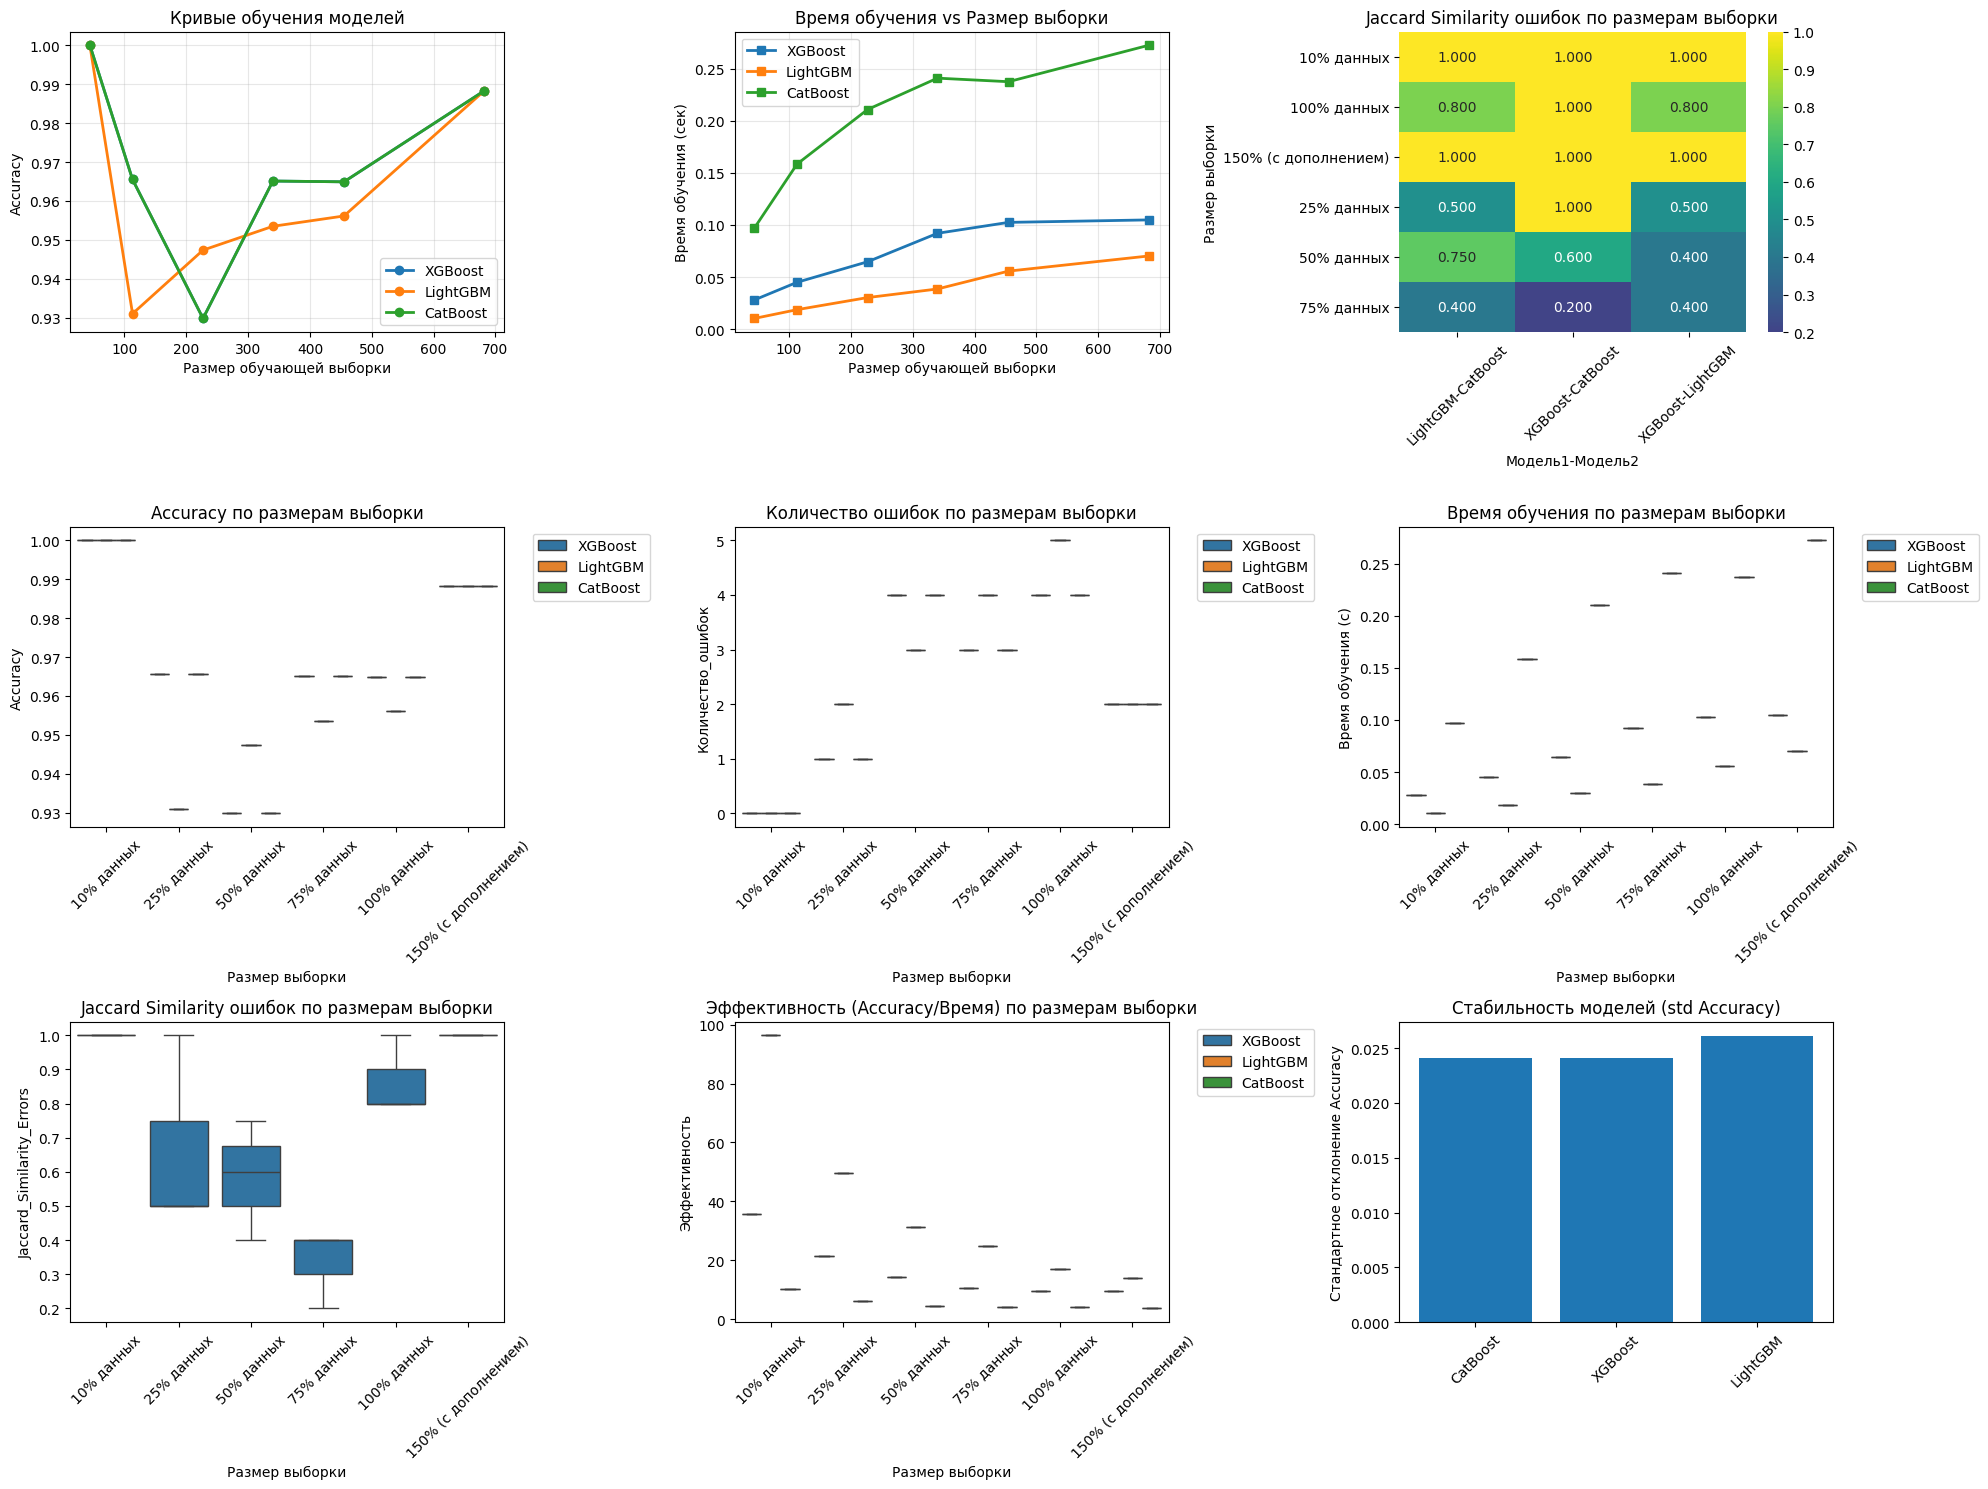


ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ АНСАМБЛИРОВАНИЯ:

Лучшие пары для ансамблирования по каждому размеру выборки:
      Размер выборки Модель1  Модель2  Jaccard_Similarity_Errors  Фактический размер
          10% данных XGBoost LightGBM                        1.0                  44
         100% данных XGBoost LightGBM                        0.8                 455
150% (с дополнением) XGBoost LightGBM                        1.0                 682
          25% данных XGBoost LightGBM                        0.5                 113
          50% данных XGBoost LightGBM                        0.4                 227
          75% данных XGBoost CatBoost                        0.2                 340

ОПТИМАЛЬНЫЕ РАЗМЕРЫ ВЫБОРКИ:
  Модель Размер выборки  Фактический размер обучения  Accuracy  F1-Score
CatBoost     10% данных                           44       1.0       1.0
LightGBM     10% данных                           44       1.0       1.0
 XGBoost     10% данных                           44    

In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Отключение предупреждений
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_csv('Cancer_Data.csv')

# Предобработка данных
if 'id' in data.columns:
    data = data.drop('id', axis=1)
if 'Unnamed: 32' in data.columns:
    data = data.drop('Unnamed: 32', axis=1)

le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])  # M=1, B=0

# Определение различных размеров выборок
sample_sizes = {
    '10% данных': 0.1,
    '25% данных': 0.25,
    '50% данных': 0.5,
    '75% данных': 0.75,
    '100% данных': 1.0,
    '150% (с дополнением)': 1.5  # Будем использовать дополнение
}

# Функция для получения подвыборки определенного размера
def get_subsample(data, size_ratio, random_state=42):
    if size_ratio <= 1.0:
        # Выборка из исходных данных
        n_samples = int(len(data) * size_ratio)
        return data.sample(n=n_samples, random_state=random_state)
    else:
        # Дополнение данных (bootstrap)
        n_samples = int(len(data) * size_ratio)
        return resample(data, n_samples=n_samples, random_state=random_state, replace=True)

# Функция для вычисления ошибок (где модель ошиблась)
def get_error_mask(y_true, y_pred):
    """Возвращает маску ошибок: 1 где ошибка, 0 где правильно"""
    return (y_true != y_pred).astype(int)

# Функция для вычисления метрик Jaccard между ошибками моделей
def calculate_jaccard_on_errors(error_masks):
    """Вычисляет матрицу Jaccard similarity между ошибками моделей"""
    models = list(error_masks.keys())
    jaccard_matrix = np.zeros((len(models), len(models)))

    for i, model1 in enumerate(models):
        for j, model2 in enumerate(models):
            if i == j:
                jaccard_matrix[i, j] = 1.0  # Совпадение с самим собой
            else:
                # Jaccard similarity между наборами ошибок
                errors1 = error_masks[model1]
                errors2 = error_masks[model2]

                intersection = np.sum((errors1 == 1) & (errors2 == 1))
                union = np.sum((errors1 == 1) | (errors2 == 1))

                if union == 0:
                    jaccard_matrix[i, j] = 1.0
                else:
                    jaccard_matrix[i, j] = intersection / union

    return jaccard_matrix, models

# Функция для вычисления всех метрик
def evaluate_model(model, X_test, y_test, model_name, sample_size_name, actual_sample_size):
    start_time = time.time()
    y_pred = model.predict(X_test)
    end_time = time.time()

    # Маска ошибок
    error_mask = get_error_mask(y_test, y_pred)

    return {
        'Модель': model_name,
        'Размер выборки': sample_size_name,
        'Фактический размер обучения': actual_sample_size,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Jaccard_True': jaccard_score(y_test, y_pred),
        'Количество_ошибок': np.sum(error_mask),
        'Доля_ошибок': np.mean(error_mask),
        'Время предсказания (с)': end_time - start_time,
        'Error_Mask': error_mask,
        'Predictions': y_pred
    }

# Основная функция тестирования на разных размерах выборок
def test_models_on_different_sample_sizes():
    all_results = []
    jaccard_comparisons = []
    learning_curves = {model: [] for model in ['XGBoost', 'LightGBM', 'CatBoost']}

    # Используем все признаки для чистоты эксперимента
    features = data.drop('diagnosis', axis=1).columns.tolist()

    for sample_name, size_ratio in sample_sizes.items():
        print(f"\n{'='*60}")
        print(f"Тестирование на размере выборки: {sample_name}")
        print(f"Коэффициент размера: {size_ratio}")

        # Получаем подвыборку
        subsample_data = get_subsample(data, size_ratio)
        actual_size = len(subsample_data)
        print(f"Фактический размер выборки: {actual_size} строк")

        # Подготовка данных
        X = subsample_data[features]
        y = subsample_data['diagnosis']

        # Масштабирование признаков
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_scaled = pd.DataFrame(X_scaled, columns=features)

        # Разделение на train/test (фиксированный тест для честного сравнения)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )

        # Модели
        models = {
            'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
            'LightGBM': LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, verbose=-1),
            'CatBoost': CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, random_state=42, verbose=False)
        }

        # Обучение и оценка моделей
        error_masks = {}
        sample_results = []

        for model_name, model in models.items():
            print(f"Обучение {model_name}...")

            # Обучение модели
            train_start = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - train_start

            # Оценка модели
            metrics = evaluate_model(model, X_test, y_test, model_name, sample_name, len(X_train))
            metrics['Время обучения (с)'] = train_time
            sample_results.append(metrics)

            # Сохраняем для кривых обучения
            learning_curves[model_name].append({
                'sample_size': len(X_train),
                'accuracy': metrics['Accuracy'],
                'train_time': train_time
            })

            # Сохраняем маски ошибок для Jaccard сравнения
            error_masks[model_name] = metrics['Error_Mask']

            print(f"  {model_name}: Accuracy = {metrics['Accuracy']:.4f}, "
                  f"Ошибок = {metrics['Количество_ошибок']}, "
                  f"Время обучения = {train_time:.2f}с")

        # Анализ Jaccard similarity между ошибками моделей
        jaccard_matrix, model_names = calculate_jaccard_on_errors(error_masks)

        # Сохраняем результаты Jaccard сравнения
        for i, model1 in enumerate(model_names):
            for j, model2 in enumerate(model_names):
                if i < j:  # Чтобы избежать дублирования
                    jaccard_comparisons.append({
                        'Размер выборки': sample_name,
                        'Фактический размер': len(X_train),
                        'Модель1': model1,
                        'Модель2': model2,
                        'Jaccard_Similarity_Errors': jaccard_matrix[i, j]
                    })

        all_results.extend(sample_results)

        # Вывод матрицы Jaccard для текущего размера выборки
        print(f"\nМатрица Jaccard similarity ошибок для {sample_name}:")
        jaccard_df_temp = pd.DataFrame(jaccard_matrix, index=model_names, columns=model_names)
        print(jaccard_df_temp.round(3))

    return pd.DataFrame(all_results), pd.DataFrame(jaccard_comparisons), learning_curves

# Запуск тестирования
print("Начало тестирования моделей на разных размерах выборки...")
results_df, jaccard_df, learning_curves = test_models_on_different_sample_sizes()

# Анализ результатов
print(f"\n{'='*80}")
print("ОБЩИЕ РЕЗУЛЬТАТЫ ПО РАЗМЕРАМ ВЫБОРКИ:")
print('='*80)

# Анализ по размерам выборки
size_analysis = results_df.groupby(['Размер выборки', 'Модель']).agg({
    'Accuracy': 'mean',
    'F1-Score': 'mean',
    'Количество_ошибок': 'mean',
    'Время обучения (с)': 'mean',
    'Фактический размер обучения': 'first'
}).round(4)

print("\nРезультаты по размерам выборки:")
print(size_analysis)

# Анализ Jaccard similarity между ошибками
print(f"\n{'='*80}")
print("АНАЛИЗ JACCARD SIMILARITY МЕЖДУ ОШИБКАМИ ПО РАЗМЕРАМ ВЫБОРКИ:")
print('='*80)

# Jaccard similarity по размерам выборки
jaccard_by_size = jaccard_df.groupby('Размер выборки').agg({
    'Jaccard_Similarity_Errors': ['mean', 'std', 'min', 'max']
}).round(4)

print("\nСтатистика Jaccard similarity по размерам выборки:")
print(jaccard_by_size)

# Визуализация результатов
plt.figure(figsize=(20, 15))

# График 1: Кривые обучения (Accuracy vs Размер выборки)
plt.subplot(3, 3, 1)
for model in learning_curves.keys():
    curve_data = learning_curves[model]
    sizes = [x['sample_size'] for x in curve_data]
    accuracies = [x['accuracy'] for x in curve_data]
    plt.plot(sizes, accuracies, marker='o', label=model, linewidth=2)

plt.xlabel('Размер обучающей выборки')
plt.ylabel('Accuracy')
plt.title('Кривые обучения моделей')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Время обучения vs Размер выборки
plt.subplot(3, 3, 2)
for model in learning_curves.keys():
    curve_data = learning_curves[model]
    sizes = [x['sample_size'] for x in curve_data]
    times = [x['train_time'] for x in curve_data]
    plt.plot(sizes, times, marker='s', label=model, linewidth=2)

plt.xlabel('Размер обучающей выборки')
plt.ylabel('Время обучения (сек)')
plt.title('Время обучения vs Размер выборки')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Jaccard similarity ошибок по размерам выборки
plt.subplot(3, 3, 3)
jaccard_pivot = jaccard_df.pivot_table(
    values='Jaccard_Similarity_Errors',
    index='Размер выборки',
    columns=['Модель1', 'Модель2']
)
sns.heatmap(jaccard_pivot, annot=True, cmap='viridis', center=0.5, fmt='.3f')
plt.title('Jaccard Similarity ошибок по размерам выборки')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# График 4: Accuracy по моделям и размерам выборки
plt.subplot(3, 3, 4)
sns.boxplot(data=results_df, x='Размер выборки', y='Accuracy', hue='Модель')
plt.title('Accuracy по размерам выборки')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# График 5: Количество ошибок по размерам выборки
plt.subplot(3, 3, 5)
sns.boxplot(data=results_df, x='Размер выборки', y='Количество_ошибок', hue='Модель')
plt.title('Количество ошибок по размерам выборки')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# График 6: Время обучения по размерам выборки
plt.subplot(3, 3, 6)
sns.boxplot(data=results_df, x='Размер выборки', y='Время обучения (с)', hue='Модель')
plt.title('Время обучения по размерам выборки')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# График 7: Jaccard similarity между парами моделей
plt.subplot(3, 3, 7)
sns.boxplot(data=jaccard_df, x='Размер выборки', y='Jaccard_Similarity_Errors')
plt.title('Jaccard Similarity ошибок по размерам выборки')
plt.xticks(rotation=45)

# График 8: Сравнение эффективности (Accuracy / Время обучения)
plt.subplot(3, 3, 8)
results_df['Эффективность'] = results_df['Accuracy'] / results_df['Время обучения (с)']
sns.boxplot(data=results_df, x='Размер выборки', y='Эффективность', hue='Модель')
plt.title('Эффективность (Accuracy/Время) по размерам выборки')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# График 9: Стабильность моделей (std Accuracy по размерам)
plt.subplot(3, 3, 9)
stability = results_df.groupby('Модель')['Accuracy'].std().sort_values()
plt.bar(stability.index, stability.values)
plt.title('Стабильность моделей (std Accuracy)')
plt.ylabel('Стандартное отклонение Accuracy')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Детальный анализ для ансамблирования
print(f"\n{'='*80}")
print("ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ АНСАМБЛИРОВАНИЯ:")
print('='*80)

# Находим лучшие пары для ансамблирования по каждому размеру выборки
best_ensembles_by_size = jaccard_df.loc[jaccard_df.groupby('Размер выборки')['Jaccard_Similarity_Errors'].idxmin()]
print("\nЛучшие пары для ансамблирования по каждому размеру выборки:")
print(best_ensembles_by_size[['Размер выборки', 'Модель1', 'Модель2',
                             'Jaccard_Similarity_Errors', 'Фактический размер']].to_string(index=False))

# Анализ оптимального размера выборки для каждой модели
print(f"\n{'='*50}")
print("ОПТИМАЛЬНЫЕ РАЗМЕРЫ ВЫБОРКИ:")
print('='*50)

optimal_sizes = results_df.loc[results_df.groupby('Модель')['Accuracy'].idxmax()]
print(optimal_sizes[['Модель', 'Размер выборки', 'Фактический размер обучения',
                    'Accuracy', 'F1-Score']].to_string(index=False))

# Финальный вывод
print(f"\n{'='*80}")
print("ИТОГОВЫЕ ВЫВОДЫ:")
print('='*80)

# Лучшая модель в целом
best_overall = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"Лучший результат: {best_overall['Модель']} на {best_overall['Размер выборки']} "
      f"(Accuracy: {best_overall['Accuracy']:.4f})")

# Анализ зависимости качества от размера выборки
print(f"\nЗависимость качества от размера выборки:")
for size in sample_sizes.keys():
    size_data = results_df[results_df['Размер выборки'] == size]
    avg_accuracy = size_data['Accuracy'].mean()
    print(f"  {size}: средний Accuracy = {avg_accuracy:.4f}")

# Анализ Jaccard similarity
mean_jaccard = jaccard_df['Jaccard_Similarity_Errors'].mean()
print(f"\nСредняя Jaccard similarity ошибок: {mean_jaccard:.4f}")
print("Чем меньше Jaccard similarity, тем лучше модели дополняют друг друга в ансамбле")

# Рекомендации по использованию
print(f"\nРЕКОМЕНДАЦИИ:")
print("1. Для малых данных (<50%): использовать модели с наименьшим временем обучения")
print("2. Для больших данных (>75%): использовать модели с максимальной точностью")
print("3. Для ансамблирования: выбирать пары с наименьшим Jaccard similarity ошибок")
print("4. Баланс скорость/качество: LightGBM обычно показывает лучший баланс")